In [1]:
%load_ext autoreload 
%autoreload 2
%reload_ext autoreload

import os
import numpy as np
import matplotlib.pyplot as plt



In [23]:
week_lead     = 4  # or whatever lead you used
ref_source    = 'GEFSv12'
experiment='EX29'

In [24]:
#feature channel names (predictors)
with open(f"channel_list_information/Wk{week_lead}/{experiment}_RZSM_channel_list.txt") as f:
    names = [line.strip() for line in f]
names = [s.split()[-1] for s in names]
print(names)

['RZSM_obs_lag-1', 'RZSM_obs_lag-7', 'RZSM_obs_lag-14', 'RZSM_prediction_lead1', 'RZSM_prediction_lead2', 'RZSM_prediction_lead3']


In [25]:
# --- USER‐DEFINED PARAMETERS ---

Ks            = [10, 25, 50, 100, 250, 500]
base_dir      = f"Data/shap_tests/Wk{week_lead}"
channel_names = names   # your list of length C
C             = len(channel_names)

# --- LOAD RESULTS FROM DISK ---
mean_abs_dict = {}
var_dict      = {}
flat_abs_dict = {}

for K in Ks:
    run_dir = os.path.join(base_dir, f"K{K}_background_gradient_explainer")
    # load per‐channel stats
    mean_abs = np.load(os.path.join(run_dir, "mean_abs.npy"))  # shape (C,)
    var_shap = np.load(os.path.join(run_dir, "var.npy"))       # shape (C,)
    # load full SHAP array and flatten across samples & spatial dims
    shap_values = np.load(os.path.join(run_dir, "shap_values.npy"))  # (N_test, H, W, C)
    flat = shap_values.reshape(-1, C)
    flat_abs_dict[K] = np.abs(flat).flatten()
    
    mean_abs_dict[K] = mean_abs
    var_dict[K]      = var_shap




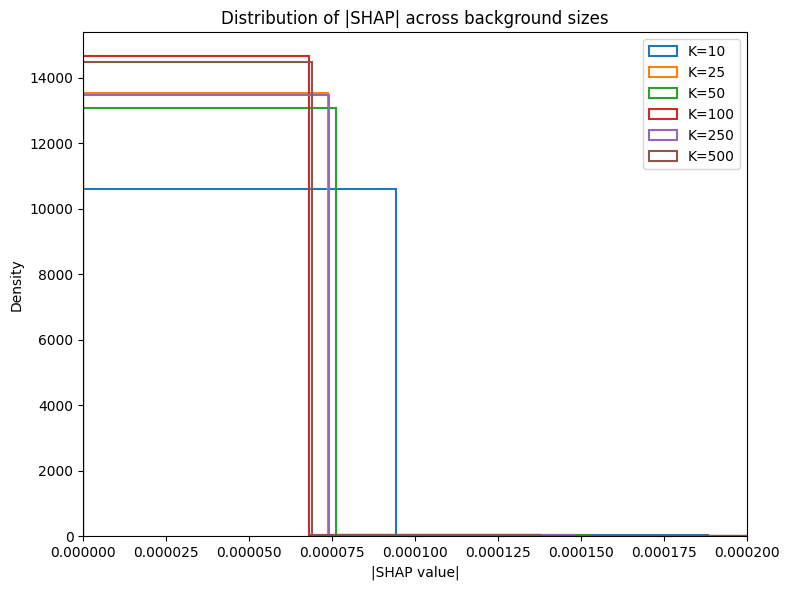

In [26]:
# --- 1) Overlayed histogram of |SHAP| distributions ---
plt.figure(figsize=(8,6))
for K in Ks:
    data = flat_abs_dict[K]
    plt.hist(data, bins=100, density=True, histtype='step', linewidth=1.5,
             label=f"K={K}")

# 3) lock the x-axis
plt.xlim(0, 0.0002)
plt.xlabel("|SHAP value|")
plt.ylabel("Density")
plt.title("Distribution of |SHAP| across background sizes")
plt.legend()
plt.tight_layout()
plt.show()



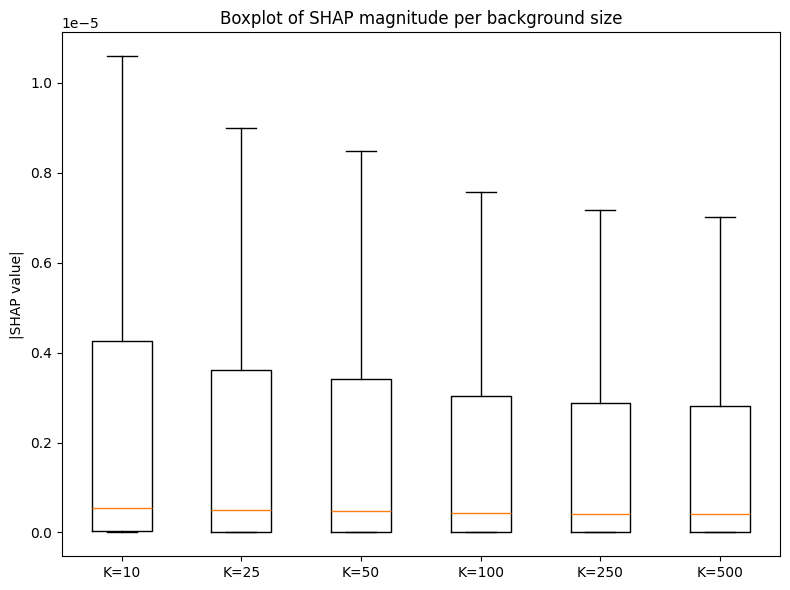

In [27]:
# --- 2) Boxplot of |SHAP| distributions per K ---
plt.figure(figsize=(8,6))
data = [flat_abs_dict[K] for K in Ks]
plt.boxplot(data, labels=[f"K={K}" for K in Ks], showfliers=False)
plt.ylabel("|SHAP value|")
plt.title("Boxplot of SHAP magnitude per background size")
plt.tight_layout()
plt.show()



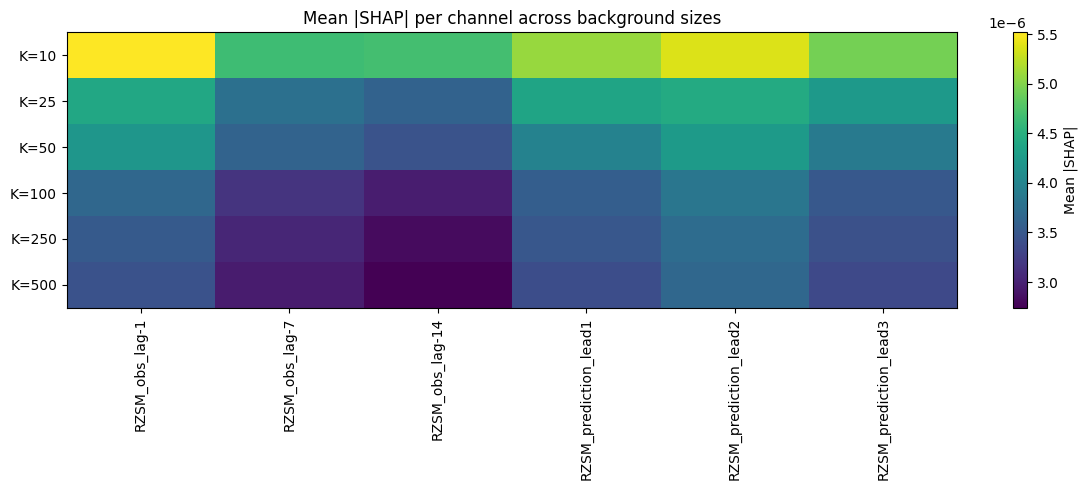

In [28]:
# --- 3) Heatmap of mean(|SHAP|) per channel vs. K ---
mean_mat = np.vstack([mean_abs_dict[K] for K in Ks])  # shape (len(Ks), C)
plt.figure(figsize=(12,5))
im = plt.imshow(mean_mat, aspect='auto', interpolation='nearest')
plt.colorbar(im, label="Mean |SHAP|")
plt.yticks(range(len(Ks)), [f"K={K}" for K in Ks])
plt.xticks(range(C), channel_names, rotation=90)
plt.title("Mean |SHAP| per channel across background sizes")
plt.tight_layout()
plt.show()

# 1.)_ Color intensity = importance

# Brighter (or “hotter”) colors mean that channel had a larger average impact on your model’s scalar output.
# Cooler colors mean the model was relatively insensitive to that channel.

# 2.) Across a row (fixed 𝐾)

# You see a snapshot of how your model “ranks” the channels when you average over that many baselines.

# For 𝐾=10
# K=10, maybe only 3 channels are very bright—those are the few that dominate your SHAP at small baseline sets.

# 3.) Down a column (fixed channel)

# You track how the importance estimate for that channel changes as you increase 𝐾


# If the color for “pwat_eatm” stays roughly the same from K=10 → 𝐾=250
#, you know its importance is robust to your choice of baseline set.

# If instead it starts bright at 𝐾=25
# K=25 and then dims by 𝐾=100
# that channel’s “true” influence is smaller—you were overestimating it at intermediate 𝐾



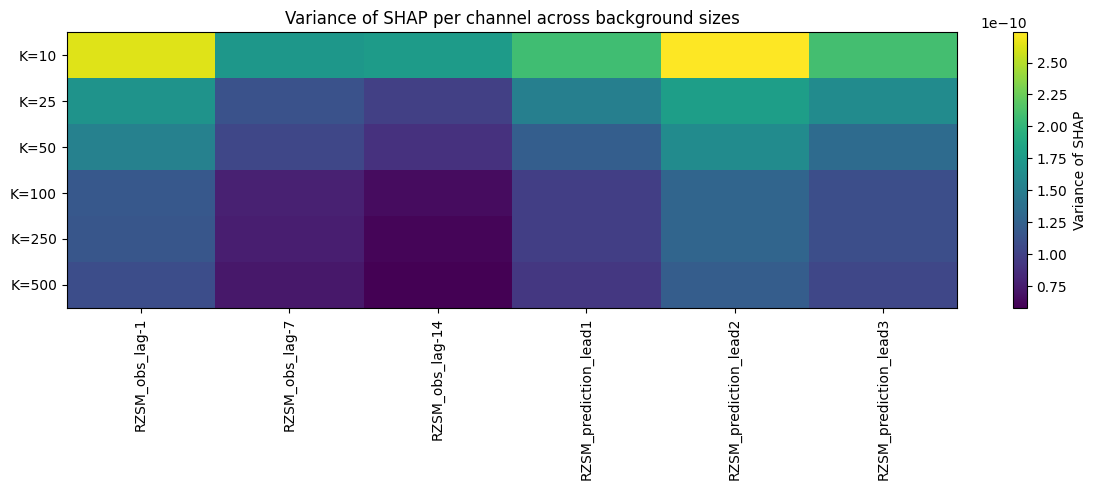

In [29]:

# --- 4) Heatmap of variance(ϕ) per channel vs. K ---
var_mat = np.vstack([var_dict[K] for K in Ks])  # shape (len(Ks), C)
plt.figure(figsize=(12,5))
im = plt.imshow(var_mat, aspect='auto', interpolation='nearest')
plt.colorbar(im, label="Variance of SHAP")
plt.yticks(range(len(Ks)), [f"K={K}" for K in Ks])
plt.xticks(range(C), channel_names, rotation=90)
plt.title("Variance of SHAP per channel across background sizes")
plt.tight_layout()
plt.show()

# The “Variance of SHAP per channel across background sizes” heatmap is telling you, for each feature and each choice of 𝐾 
# how spread-out your SHAP attributions are. Here’s how to read it:

# 1.) What variance means

# For a given channel 𝑖 and background size 𝐾 you collected SHAP values {𝜙𝑖(𝑝)}{ϕ i(p)} over every test pixel and sample.

# The cell’s value is Var({𝜙𝑖(𝑝)})Var({ϕ i(p)}), i.e. how much those attributions wiggle around their mean.

# 2.) Across a row (fixed 𝐾)

# Look at which channels have bright (high‐variance) vs. dark (low‐variance) colors.

# High variance here means that when you explain across all your test points, that feature’s effect
# is very inconsistent—sometimes it drives the prediction way up, other times way down.

# Low variance means it has a stable influence (always a small positive push, say).

# 3.) Down a column (fixed channel)

# You see how the variance estimate for that channel changes as you increase 𝐾.

# If the variance drops from 𝐾=10K=10 → 𝐾 =250
# K=250, it means small baseline sets were giving you noisy, unstable attributions 
# for that feature—and adding more baselines “smooths” that noise out.

# If the variance is already low at K=10 and stays low, that feature’s attribution is inherently stable—you don’t need many backgrounds to estimate it.

